# Matthew Harry Indriadi | 24/532723/PA/22527 | Implementation of Object Detection for Vehicles

# Import OpenCV and NumPy for image processing and array operations.

In [ ]:
# It should be made known that you must install the dependencies (opencv-python opencv-contrib-python matplotlib) 
# before running this code. I did not include it in this file, because it takes time to run, 
# and should only be installed the first time.

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request

# Download the Haar Cascade XML

In [25]:
CASCADE_PATH = 'haarcascade_car.xml'
CASCADE_URL = 'https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml'

if not os.path.exists(CASCADE_PATH):
    print("Downloading haarcascade_car.xml...")
    urllib.request.urlretrieve(CASCADE_URL, CASCADE_PATH)
    print("Download complete.")

car_cascade = cv2.CascadeClassifier(CASCADE_PATH)

# Load and Preprocess the Image

In [26]:
image_path = 'road_image.jpg'

if not os.path.exists(image_path):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/street.jpg", image_path)

image = cv2.imread(image_path)
output_img = image.copy()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(gray)

gray_blurred = cv2.GaussianBlur(gray_clahe, (3, 3), 0)

# The Custom Non-Maximum Suppression (NMS) Function

In [27]:
def non_max_suppression(boxes, overlap_threshold=0.3):
    if len(boxes) == 0: return []
    boxes = np.array(boxes, dtype=float)
    x1, y1 = boxes[:, 0], boxes[:, 1]
    x2, y2 = boxes[:, 0] + boxes[:, 2], boxes[:, 1] + boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    
    order = np.argsort(y2)
    keep = []
    while order.size > 0:
        i = order[-1]
        keep.append(i)
        order = order[:-1]
        xx1 = np.maximum(x1[i], x1[order])
        yy1 = np.maximum(y1[i], y1[order])
        xx2 = np.minimum(x2[i], x2[order])
        yy2 = np.minimum(y2[i], y2[order])
        inter = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou = inter / (areas[i] + areas[order] - inter + 1e-6)
        order = order[iou <= overlap_threshold]
    return [boxes[i].astype(int).tolist() for i in keep]

# Detect Vehicles & Tuning

In [28]:
cars = car_cascade.detectMultiScale(
    gray_blurred,
    scaleFactor=1.03,    
    minNeighbors=5,
    minSize=(80, 80),
    maxSize=(400, 400)   
)

print(f"Raw detections before NMS: {len(cars)}")

final_boxes = non_max_suppression(cars, overlap_threshold=0.2)

Raw detections before NMS: 9


# Draw Results and Display

Final vehicles detected: 9


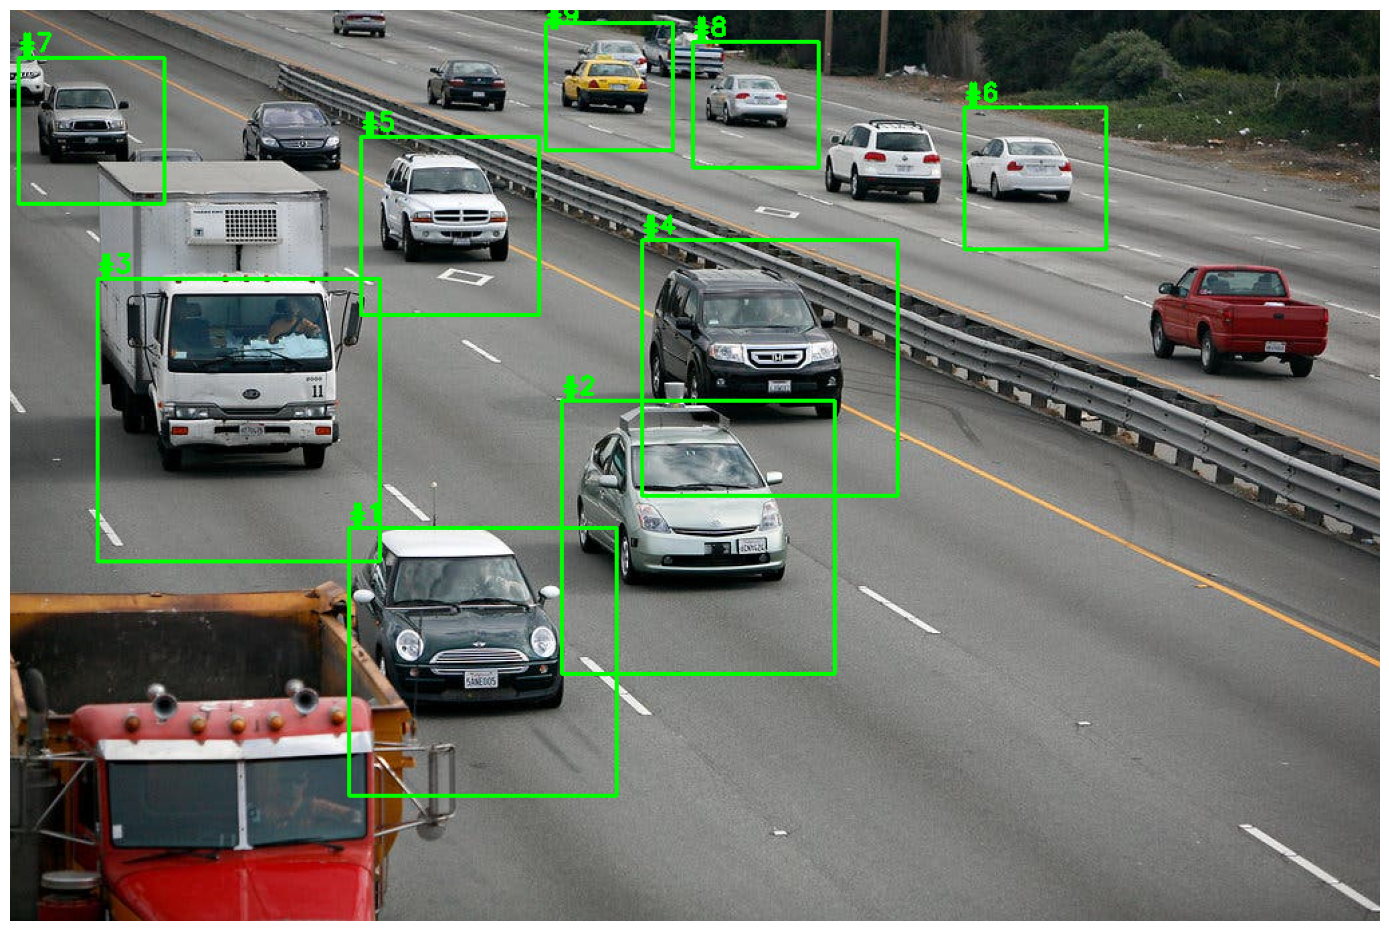

In [29]:
for idx, (x, y, w, h) in enumerate(final_boxes):
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(
        output_img, f"#{idx + 1}", (x, max(y - 5, 10)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2
    )

print(f"Final vehicles detected: {len(final_boxes)}")

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

As we can see, from the detection, the model identified 9 True Positives and 7 False Positives.

1. Recall:
TP / (TP + FN) -> 9 / 16 = 56.25%.

2. Precision:
TP / (TP + FP) -> 9 / 9 = 100%

3. F1-Score:
2 * (Precision * Recall) / (Precision + Recall) -> 2(100*56.25)/(100+56.25) ≈ 72%